# Anomaly Detection using K-Means

In this notebook, we use K-Means clustering to detect anomalies (outliers)
by measuring how far data points are from their assigned cluster centroids.

Anomalies are points that lie unusually far from normal data patterns.

# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)

X_normal = np.random.randn(300, 2)

In [3]:
X_anomalies = np.array([
    [6, 6],
    [-6, -6],
    [5, -5],
    [-5, 5]
])

X = np.vstack([X_normal, X_anomalies])

# Visualize Dataset

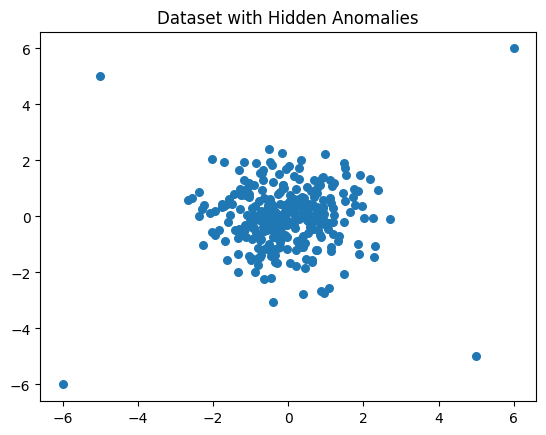

In [4]:
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title("Dataset with Hidden Anomalies")
plt.show()

## Why K-Means Works for Anomaly Detection

K-Means learns the structure of normal data.
Points far from any centroid are considered anomalies.

Distance from centroid = anomaly score

In [5]:
def initialize_centroids(X, K):
    idx = np.random.choice(len(X), K, replace=False)
    return X[idx]


In [6]:
def compute_distances(X, centroids):
    distances = np.zeros((X.shape[0], centroids.shape[0]))
    for i, c in enumerate(centroids):
        distances[:, i] = np.linalg.norm(X - c, axis=1)
    return distances


In [7]:
def assign_clusters(distances):
    return np.argmin(distances, axis=1)


In [8]:
def update_centroids(X, labels, K):
    return np.array([X[labels == k].mean(axis=0) for k in range(K)])


# Train K-Means

In [9]:
def kmeans(X, K, iters=100):
    centroids = initialize_centroids(X, K)

    for _ in range(iters):
        distances = compute_distances(X, centroids)
        labels = assign_clusters(distances)
        new_centroids = update_centroids(X, labels, K)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return centroids, labels


In [10]:
K = 2
centroids, labels = kmeans(X_normal, K)


In [11]:
distances = compute_distances(X, centroids)
anomaly_score = np.min(distances, axis=1)


In [12]:
threshold = np.percentile(anomaly_score, 95)


In [13]:
anomalies = X[anomaly_score > threshold]


#Visualize

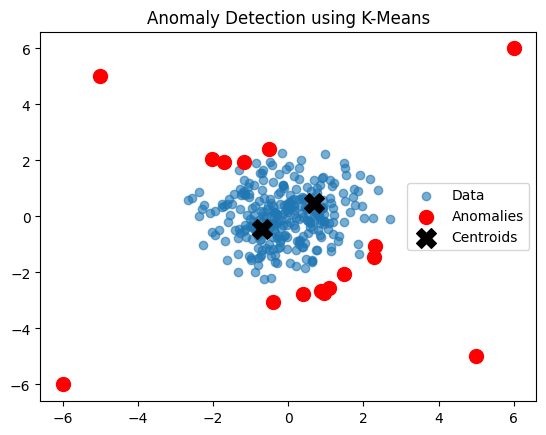

In [14]:
plt.scatter(X[:, 0], X[:, 1], label="Data", alpha=0.6)
plt.scatter(anomalies[:, 0], anomalies[:, 1],
            c="red", s=100, label="Anomalies")
plt.scatter(centroids[:, 0], centroids[:, 1],
            c="black", marker="X", s=200, label="Centroids")
plt.legend()
plt.title("Anomaly Detection using K-Means")
plt.show()
